# Step 4 - The NeuralProphet pipeline

This is one of four `step4_model_*` notebooks, one per model architecture. Read them after step 1 (data splitting), step 2 (cross-validation), and step 5 (hyperparameter tuning -- demoed on `prophet_xgb`). Step 5 shows *where* a final set of hyperparameters comes from; here we fit the model with the package defaults from `params.yaml` and inspect its behavior. To run this notebook with tuned parameters instead, pass `config_overrides={"models": {"neuralprophet": best_params}}` into `run_single_its()`.

**Goal:** walk through `run_single_its()` using the `NeuralProphetModel`.

Sections:
- **4a.** Load the pre-built dummy data.
- **4b.** Fit `NeuralProphetModel` manually and inspect the `FitResult`.
- **4c.** Inside NeuralProphet -- AR terms and the warmup period.
- **4d.** Run the full pipeline via `run_single_its()`.
- **4e.** Inspect `PipelineResult`: metrics, excess table, ATE.
- **4f.** Reproduce the counterfactual plot with annotations.

In [1]:
%matplotlib inline

from IPython.display import display
import logging
import warnings
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)s  %(name)s - %(message)s",
    datefmt="%H:%M:%S",
)
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
logging.getLogger("its2s").setLevel(logging.WARNING)
logging.getLogger("NP").setLevel(logging.CRITICAL)

OUT_DIR = Path.cwd() / "figures"
OUT_DIR.mkdir(exist_ok=True)
INTERVENTION = "2022-03-15"
TEST_DAYS    = 365
HOLDOUT_DAYS = 42

## 4a. Load the pre-built dummy data

The series has a +8/day intervention effect baked in for 42 days after 2022-03-15.

In [2]:
df = pd.read_csv("data/dummy_data.csv", parse_dates=["ds"])

print("=" * 60)
print("Dummy dataset (with +8/day intervention effect)")
print("=" * 60)
print(df.tail())

Dummy dataset (with +8/day intervention effect)
             ds          y  covar_linear  covar_dow  covar_noise
1571 2022-04-21  71.975041      0.995182        3.0    -0.356611
1572 2022-04-22  73.042307      1.033630        4.0     0.247103
1573 2022-04-23  72.275013      1.003513        5.0     1.129482
1574 2022-04-24  69.332534      1.004775        6.0    -0.321536
1575 2022-04-25  69.651058      0.981820        0.0    -1.057655


## 4b. Manual fit

This replicates what `run_single_its` does internally, so we can inspect the `FitResult`.

NeuralProphet trains a neural network, so this cell takes longer than ARIMA or Prophet-based models.

In [3]:
from its2s.data_prep import prepare_splits
from its2s.models.neuralprophet import NeuralProphetModel
from its2s.settings import get_model_config, load_config

config = load_config()
splits = prepare_splits(df, INTERVENTION, split_method="days", test_days=TEST_DAYS, holdout_days=HOLDOUT_DAYS)

model_params = get_model_config(config, "neuralprophet")
model = NeuralProphetModel(params=model_params)

print("Fitting NeuralProphetModel on training data ...")
print(f"  Training rows : {len(splits.train_df)}")
print(f"  Training range: {splits.train_df['ds'].min().date()} -> {splits.train_df['ds'].max().date()}")
print(f"  n_lags        : {model_params.get('n_lags', 14)}")
print(f"  epochs        : {model_params.get('epochs', 100)}")

fit_result = model.fit(splits.train_df, target_col="y", date_col="ds")

n_nan = int(np.isnan(fit_result.fitted_values).sum())
n_lags = model_params.get("n_lags", 14)
print("\nFitResult fields:")
print(f"  fitted_values  shape = {fit_result.fitted_values.shape}")
print(f"  residuals      shape = {fit_result.residuals.shape}")
print(f"  NaN fitted values   = {n_nan}  (AR warmup = n_lags = {n_lags})")
print(f"  residuals  mean={np.nanmean(fit_result.residuals):.4f}  std={np.nanstd(fit_result.residuals):.4f}  (NaNs excluded)")

Fitting NeuralProphetModel on training data ...
  Training rows : 1169
  Training range: 2018-01-01 -> 2021-03-14
  n_lags        : 14
  epochs        : 100


Training: 0it [00:00, ?it/s]

Training:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1:   0%|          | 0/100 [00:00<?, ?it/s] 

Epoch 1:   1%|          | 1/100 [00:00<00:00, 1829.18it/s]

...

Predicting:   0%|          | 0/2 [00:00<-00:00, -1695569.70it/s]

Predicting DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]  

Predicting DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 893.93it/s]

Predicting DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 758.40it/s]



FitResult fields:
  fitted_values  shape = (1169,)
  residuals      shape = (1169,)
  NaN fitted values   = 14  (AR warmup = n_lags = 14)
  residuals  mean=-0.0095  std=2.2023  (NaNs excluded)


## 4c. Inside NeuralProphet -- AR terms and the warmup period

NeuralProphet uses autoregressive (AR) lags: to predict observation `t`, it uses the
observed values at observations `t-1` through `t-n_lags`. `n_lags` counts observations
of the series, not calendar days (the two coincide here because the dummy data is daily). This means the first `n_lags` rows cannot produce a
prediction because there is no history yet -- they form the **AR warmup period** and produce
NaN fitted values and residuals.

This has a practical implication for Moving Block Bootstrap: the bootstrap resamples
only the non-NaN residuals. The available residuals are `total_train_rows - n_lags`.

In [4]:
final_metrics = fit_result.metadata.get("final_metrics")
if final_metrics is not None:
    print("Training loss (last 5 epochs):")
    print(final_metrics.tail().to_string(index=False))

n_lags       = model_params.get("n_lags", 14)
n_train      = len(splits.train_df)
n_valid_resid = int(np.isfinite(fit_result.residuals).sum())
print(f"\n  Total training rows      : {n_train}")
print(f"  AR warmup rows (n_lags)  : {n_lags}")
print(f"  Valid (non-NaN) residuals: {n_valid_resid}")
print(f"  -> MBB will resample from {n_valid_resid} residuals")

Training loss (last 5 epochs):
     MAE     RMSE     Loss  RegLoss  epoch
1.775751 2.211107 0.009065      0.0     95
1.759129 2.170924 0.008893      0.0     96
1.700649 2.118625 0.008615      0.0     97
1.754008 2.181051 0.008892      0.0     98
1.716331 2.146283 0.008666      0.0     99

  Total training rows      : 1169
  AR warmup rows (n_lags)  : 14
  Valid (non-NaN) residuals: 1155
  -> MBB will resample from 1155 residuals


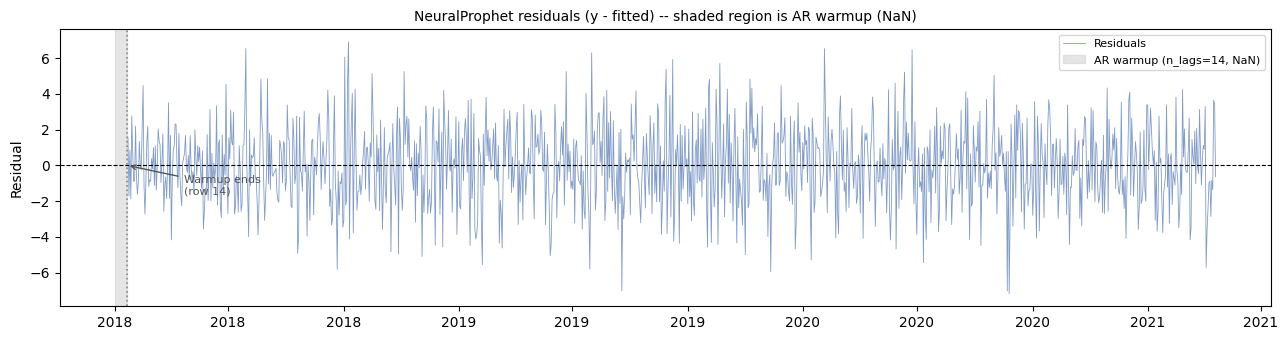

In [5]:
dates    = splits.train_df["ds"].values
residuals = fit_result.residuals
warmup_end = splits.train_df["ds"].iloc[n_lags - 1]

fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(dates, residuals, linewidth=0.6, color="#4C72B0", alpha=0.7, label="Residuals")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

# Shade the warmup region
ax.axvspan(dates[0], warmup_end, color="#CCCCCC", alpha=0.5, label=f"AR warmup (n_lags={n_lags}, NaN)")
ax.axvline(pd.Timestamp(warmup_end), color="#888888", linestyle=":", linewidth=1.2)
ax.annotate(
    f"Warmup ends\n(row {n_lags})",
    xy=(pd.Timestamp(warmup_end), 0),
    xytext=(pd.Timestamp(warmup_end) + pd.Timedelta(days=60), residuals[n_lags + 10]),
    arrowprops=dict(arrowstyle="->", color="#555555"),
    fontsize=8,
    color="#555555",
)

ax.set_title("NeuralProphet residuals (y - fitted) -- shaded region is AR warmup (NaN)", fontsize=10)
ax.set_ylabel("Residual")
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.savefig(OUT_DIR / "neuralprophet_residuals.png", dpi=150)
display(fig)

## 4d. Full pipeline run

MBB bootstrap runs with `n_sim=100` for speed; production use should set this to 1000+.
Expect this cell to take longer than ARIMA or Prophet models due to neural network training.

In [6]:
from its2s import run_single_its

result = run_single_its(
    df=df,
    intervention_date=INTERVENTION,
    model_name="neuralprophet",
    config_overrides={
        "bootstrap": {"n_sim": 100},
        "periods":   {"split_method": "days", "test_days": TEST_DAYS, "holdout_days": HOLDOUT_DAYS},
    },
    output_dir=OUT_DIR,
    seed=42,
)

print("PipelineResult fields:")
print(f"  model_name       : {result.model_name}")
print(f"  fit_result       : FitResult with {len(result.fit_result.fitted_values)} fitted values")
print(f"  bootstrap_result : BootstrapCIResult  pred_matrix shape = {result.bootstrap_result.pred_matrix.shape}")
print(f"  n_successful sims: {result.bootstrap_result.n_successful}")
print(f"  metrics_train    : {result.metrics_train}")
print(f"  metrics_test     : {result.metrics_test}")

Training: 0it [00:00, ?it/s]

Training:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1:   0%|          | 0/100 [00:00<?, ?it/s] 

Epoch 1:   1%|          | 1/100 [00:00<00:00, 2809.31it/s]

Epoch 1:   1%|          | 1/100 [00:00<00:02, 38.96it/s, loss=1.58, v_num=17, MAE=55.30, RMSE=67.10, Loss=1.580, RegLoss=0.000]

...

Predicting:   0%|          | 0/2 [00:00<-00:00, -1048576.00it/s]

Predicting DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]  

Predicting DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 752.68it/s]

Predicting DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 664.18it/s]

PipelineResult fields:
  model_name       : neuralprophet
  fit_result       : FitResult with 1169 fitted values
  bootstrap_result : BootstrapCIResult  pred_matrix shape = (407, 100)
  n_successful sims: 0
  metrics_train    : MetricsResult(rmse=3.008841134522328, mae=2.415157090262152, mape=4.715230099525625, mase=None, mase_m=7, mase_denominator=None)
  metrics_test     : MetricsResult(rmse=3.189931623510256, mae=2.5421783625209797, mape=4.803648382383328, mase=1.105892374419183, mase_m=7, mase_denominator=2.298757475252632)


## 4e. Metrics and excess table

MASE is reported for the held-out test window only (the Train cell is NaN by design):
it is the ratio of the model's MAE to the in-sample MAE of the seasonal-naive forecast
at the resolved period `m` (`mase_m` and `mase_denominator` on the result). A value
below 1 means the model beats the seasonal-naive benchmark. The test window serves as
a single-use adequacy check of the fitted model, not a retuning target.


In [7]:
metrics_df = pd.DataFrame({
    "RMSE":  [result.metrics_train.rmse,  result.metrics_test.rmse],
    "MAE":   [result.metrics_train.mae,   result.metrics_test.mae],
    "MAPE":  [result.metrics_train.mape,  result.metrics_test.mape],
    "MASE":  [result.metrics_train.mase,  result.metrics_test.mase],
}, index=["Train", "Test"])
print(metrics_df.round(3).to_string())

mt = result.metrics_test
print(f"\nMASE benchmark: in-sample seasonal-naive MAE = "
      f"{mt.mase_denominator:.3f} at m = {mt.mase_m}")


        RMSE    MAE   MAPE   MASE
Train  3.009  2.415  4.715    NaN
Test   3.190  2.542  4.804  1.106

MASE benchmark: in-sample seasonal-naive MAE = 2.299 at m = 7


In [8]:
print("Period-level excess:")
print(result.excess_table.period_excess.to_string(index=False))
print("\nDaily excess - first 10 holdout days:")
print(result.excess_table.obs_excess.head(10).to_string(index=False))

Period-level excess:
      period start_date   end_date  n_obs  total_observed  total_expected  total_excess  excess_ci_lo  excess_ci_hi  excess_pct
Full holdout 2022-03-15 2022-04-25     42     3029.800778     2970.226562     59.574215   3029.800778   3029.800778    2.005713

Daily excess - first 10 holdout days:
      date  observed  expected  expected_ci_lo  expected_ci_hi    excess  excess_ci_lo  excess_ci_hi  excess_pct  excess_pct_ci_lo  excess_pct_ci_hi
2022-03-15 76.449700 64.602005             NaN             NaN 11.847695           NaN           NaN   18.339516               NaN               NaN
2022-03-16 70.565458 65.051552             NaN             NaN  5.513906           NaN           NaN    8.476210               NaN               NaN
2022-03-17 74.032036 68.638535             NaN             NaN  5.393501           NaN           NaN    7.857833               NaN               NaN
2022-03-18 69.205309 64.688263             NaN             NaN  4.517046           NaN  

**Note — NaN confidence intervals (known limitation).** All CI columns (`expected_ci_lo`, `expected_ci_hi`, `excess_ci_lo`, `excess_ci_hi`) are NaN because all 100 bootstrap simulations failed (`n_successful = 0` above). The root cause is NeuralProphet's AR warmup: the first `n_lags` rows of `fit_result.fitted_values` are NaN, and Moving Block Bootstrap builds the perturbed training series as `fitted_values + resampled_residuals` — leaving those rows as NaN. NeuralProphet cannot refit on a training series with NaN target values, so every simulation errors out. This is a known incompatibility between NeuralProphet and the current MBB implementation; a fix is tracked in a separate issue.

In [9]:
from its2s.metrics.excess import calc_ate_summary

ate = calc_ate_summary(result.excess_table.obs_excess)
print("Average Treatment Effect (ATE) summary:")
print(ate.to_string(index=False))
print("\n  Total ATE      = sum of daily excess over full holdout")
print("  Mean ATE per obs = average excess per observation")
print(f"  Simulated effect was +8/day for {HOLDOUT_DAYS} days -> expected total excess ~{8 * HOLDOUT_DAYS}")

Average Treatment Effect (ATE) summary:
          metric  estimate  ci_lo  ci_hi  n_obs
       Total ATE 59.574105    0.0    0.0     42
Mean ATE per obs  1.418431    0.0    0.0     42

  Total ATE      = sum of daily excess over full holdout
  Mean ATE per obs = average excess per observation
  Simulated effect was +8/day for 42 days -> expected total excess ~336


## 4f. Counterfactual plot (annotated)

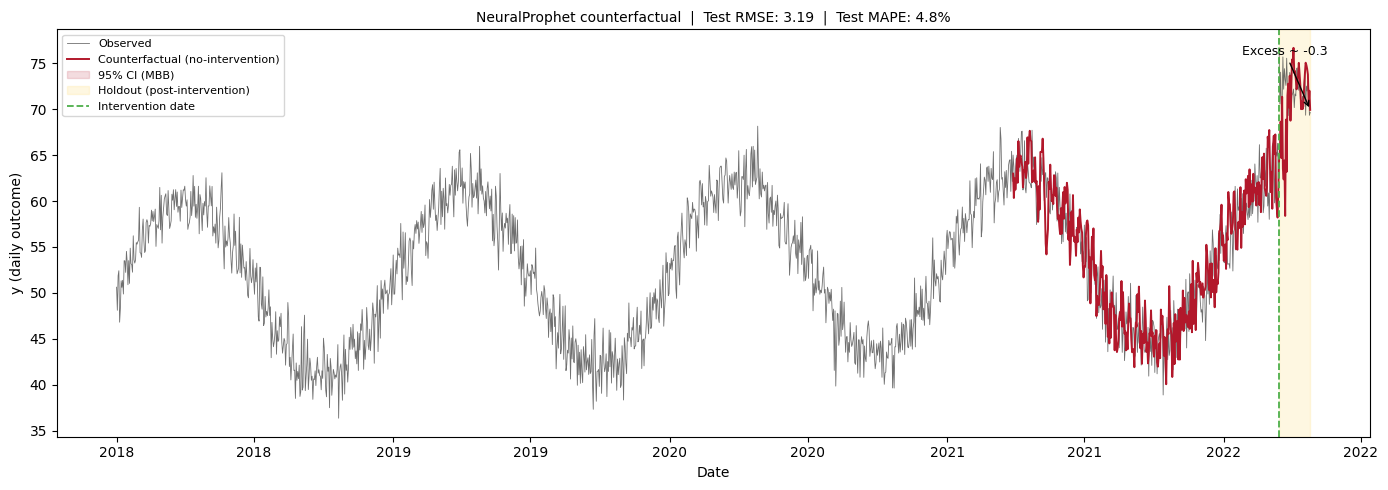

In [10]:
br = result.bootstrap_result
pred_dates = pd.to_datetime(br.dates)
intervention_ts = pd.Timestamp(INTERVENTION)

fig, ax = plt.subplots(figsize=(14, 5))

for part in [splits.train_df, splits.test_df, splits.holdout_df]:
    ax.plot(part["ds"], part["y"], color="#333333", linewidth=0.6, alpha=0.7)
ax.plot([], [], color="#333333", linewidth=0.6, alpha=0.7, label="Observed")

ax.plot(pred_dates, br.predicted, color="#B2182B", linewidth=1.4,
        label="Counterfactual (no-intervention)")
ax.fill_between(pred_dates, br.conf_lo, br.conf_hi,
                color="#B2182B", alpha=0.15, label="95% CI (MBB)")

ax.axvspan(intervention_ts, splits.holdout_df["ds"].max(),
           color="#FEE08B", alpha=0.25, label="Holdout (post-intervention)")
ax.axvline(intervention_ts, color="#4DAF4A", linestyle="--", linewidth=1.3,
           label="Intervention date")

last_date = pred_dates[pred_dates >= intervention_ts][-1]
last_obs  = splits.holdout_df.loc[splits.holdout_df["ds"] == last_date, "y"].values
last_pred = br.predicted[pred_dates == last_date]
if len(last_obs) and len(last_pred):
    ax.annotate(
        f"Excess ~ {float(last_obs[0] - last_pred[0]):.1f}",
        xy=(last_date, float(last_pred[0])),
        xytext=(last_date - pd.Timedelta(days=90), float(last_pred[0]) + 6),
        arrowprops=dict(arrowstyle="->", color="black"),
        fontsize=9,
    )

ax.set_xlabel("Date")
ax.set_ylabel("y (daily outcome)")
ax.set_title(
    f"NeuralProphet counterfactual  |  Test RMSE: {result.metrics_test.rmse:.2f}"
    f"  |  Test MAPE: {result.metrics_test.mape:.1f}%",
    fontsize=10,
)
ax.legend(loc="upper left", fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.savefig(OUT_DIR / "neuralprophet_counterfactual.png", dpi=150)
display(fig)

## Key takeaways

1. `NeuralProphetModel.fit()` trains a neural network with `n_lags` autoregressive terms and optional lagged regressors. Training is slower than statistical or tree-based models.
2. The AR warmup period: the first `n_lags` rows cannot produce a fitted value because there is no preceding history. These rows yield NaN in `fit_result.fitted_values` and `fit_result.residuals`.
3. Moving Block Bootstrap resamples only the non-NaN residuals. The effective residual pool is `n_train_rows - n_lags`.
4. `run_single_its()` orchestrates: `load_config -> prepare_splits -> fit -> bootstrap -> metrics -> excess -> save`.
5. Excess = observed - counterfactual_predicted. With a true +8/day effect over 42 days, total excess should land near 336 (noise aside).